In [1]:
# %%
# %matplotlib inline
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json
from typing import Dict, List, Tuple, Optional, Union
import os
from crosscoder import BatchTopKCrosscoder
from transformers import AutoTokenizer, AutoModelForCausalLM
from data_utils import get_activations, BOS_TOKEN_ID, USER_TOKEN_ID, ASSISTANT_TOKEN_ID
from datasets import load_dataset

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for CUDA
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
def load_crosscoder_model(model_path: str) -> BatchTopKCrosscoder:
    """Load the trained crosscoder model"""
    # Add PosixPath to safe globals for loading
    from pathlib import PosixPath
    import torch.serialization
    torch.serialization.add_safe_globals([PosixPath])
    
    # Load checkpoint
    checkpoint = torch.load(model_path, weights_only=False)
    
    # Extract model parameters
    d_model = checkpoint['W_encoder_ZF'].shape[0] // 2  # Divide by 2 since it's concatenated
    dict_size = checkpoint['W_encoder_ZF'].shape[1]
    k = checkpoint.get('k', 40)  # Default k if not specified
    
    # Create model and load state
    model = BatchTopKCrosscoder(d_model=d_model, dict_size=dict_size, k=k)
    model.load_state_dict(checkpoint)
    
    return model

# Load the crosscoder model
model_path = "crosscoder-layer14_49152_100_fullshuffle_aux.pt"
crosscoder = load_crosscoder_model(model_path)
crosscoder.to(device)
print(f"Loaded crosscoder model with {crosscoder.dict_size} features")

Loaded crosscoder model with 49152 features


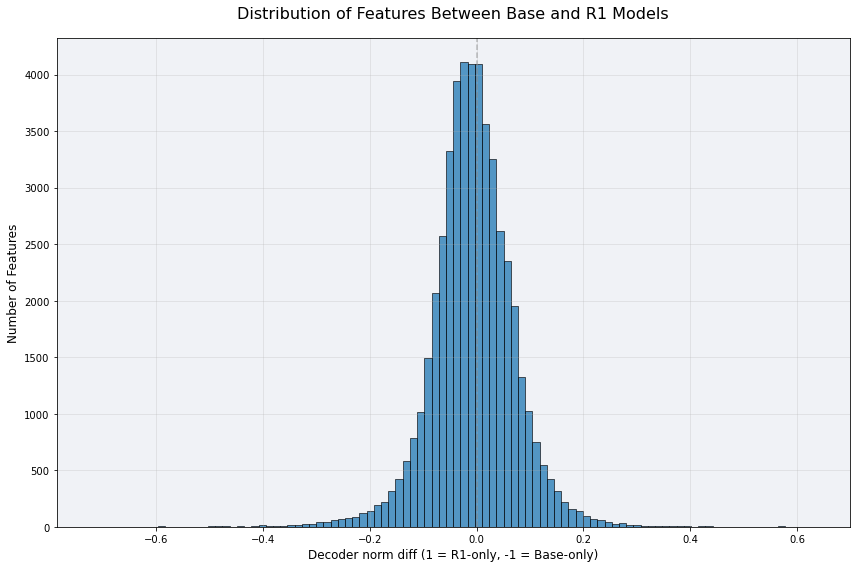

In [4]:
def analyze_decoder_norm_diffs(decoder_A: torch.Tensor, decoder_B: torch.Tensor) -> np.ndarray:
    """
    Analyze decoder norm differences to understand feature exclusivity.
    Returns values between -1 (base model only) and 1 (R1 model only).
    
    Args:
        decoder_A: Decoder weights for base model [dict_size, d_model]
        decoder_B: Decoder weights for R1 model [dict_size, d_model]
        
    Returns:
        Array of norm differences, normalized to [-1, 1]
    """
    # Calculate norms across the d_model dimension
    norm_A = torch.norm(decoder_A, dim=1)  # Shape: [dict_size]
    norm_B = torch.norm(decoder_B, dim=1)  # Shape: [dict_size]
    
    # Calculate normalized difference
    # (B-A)/(B+A) will be:
    # 1 when B >> A (R1 only)
    # -1 when A >> B (base only)
    # 0 when A ≈ B (shared)
    norm_diff = (norm_B - norm_A) / (norm_B + norm_A + 1e-10)
    
    return norm_diff.cpu().numpy()

# Get decoder weights
decoder_weights = crosscoder.W_decoder_FZ.data  # Shape: [dict_size, 2*d_model]
d_model = decoder_weights.shape[1] // 2

# Split decoder weights for base and R1 models
decoder_A = decoder_weights[:, :d_model]  # Shape: [dict_size, d_model]
decoder_B = decoder_weights[:, d_model:]  # Shape: [dict_size, d_model]

# Calculate decoder norm differences
norm_diffs = analyze_decoder_norm_diffs(decoder_A, decoder_B)

# Create a DataFrame for easier analysis
df = pd.DataFrame({'feature_id': np.arange(len(norm_diffs)), 'dec_norm_diff': norm_diffs })

# Plot the distribution of norm differences
plt.figure(figsize=(12, 8))
sns.histplot(data=df['dec_norm_diff'], bins=100)
plt.title('Distribution of Features Between Base and R1 Models', fontsize=16, pad=20)
plt.xlabel('Decoder norm diff (1 = R1-only, -1 = Base-only)', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.grid(True, alpha=0.3)
plt.gca().set_facecolor('#F0F2F6')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
# Sort features by norm difference
df_sorted = df.sort_values(by='dec_norm_diff')

# Display the most base-exclusive features
print("Most Base-exclusive features:")
display(df_sorted.head(10))

# Display the most R1-exclusive features
print("\nMost R1-exclusive features:")
display(df_sorted.tail(10))

Most Base-exclusive features:


,feature_id,dec_norm_diff
193,193,-0.718330
10946,10946,-0.693451
4783,4783,-0.645346
26020,26020,-0.641761
33867,33867,-0.626092
33174,33174,-0.621748
21466,21466,-0.591893
13125,13125,-0.589734
17037,17037,-0.589200
36234,36234,-0.522014



Most R1-exclusive features:


,feature_id,dec_norm_diff
245,245,0.533536
35164,35164,0.553761
47006,47006,0.564910
17992,17992,0.572656
26749,26749,0.575989
12687,12687,0.582434
47069,47069,0.582665
31882,31882,0.597606
14615,14615,0.618306
25692,25692,0.630714


In [6]:
# Load base model
base_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-Math-1.5B", device_map=device, torch_dtype=torch.bfloat16)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B")

# Load R1 model
r1_tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B")
r1_model = AutoModelForCausalLM.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B", device_map=device, torch_dtype=torch.bfloat16)

2025-04-09 21:17:08.190525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744233428.213597 2209291 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744233428.220966 2209291 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


In [47]:
def get_crosscoder_activations(prompt: str, response: str, layer_num: int = 14, ctx_len=1024):
    """Get crosscoder activations for a given prompt"""
    # Tokenize the prompt
    prompt_tokens = r1_tokenizer(prompt, add_special_tokens=False)["input_ids"]
    response_tokens = r1_tokenizer(response)["input_ids"][1:]  # remove BOS from response
    
    # Add special tokens
    tokens = [BOS_TOKEN_ID] + [USER_TOKEN_ID] + prompt_tokens + [ASSISTANT_TOKEN_ID] + response_tokens
    tokens = tokens[:ctx_len]
    tokens = torch.tensor(tokens).unsqueeze(0).to(device)
    
    # Get activations from both models
    with torch.no_grad():
        base_activations = get_activations(base_model, tokens, layer_num)
        r1_activations = get_activations(r1_model, tokens, layer_num)
    
    # Concatenate activations
    concatenated_activations = torch.cat([base_activations, r1_activations], dim=-1)
    
    # Reshape to match crosscoder input format
    batch_size, seq_len, hidden_size = concatenated_activations.shape
    reshaped_activations = concatenated_activations.reshape(-1, hidden_size)
    
    # Get crosscoder features
    with torch.no_grad():
        crosscoder_output = crosscoder(reshaped_activations.to(torch.float32))
        features = crosscoder_output["sparse_activations"]
    
    # Reshape features back to [batch_size, seq_len, dict_size]
    features = features.reshape(batch_size, seq_len, -1)
    
    return features, tokens

def visualize_features(prompt: str, response: str, feature_ids: List[int], layer_num: int = 14):
    """Visualize feature activations for a given prompt"""
    features, tokens = get_crosscoder_activations(prompt, response, layer_num)
    
    # Decode tokens
    decoded_tokens = r1_tokenizer.batch_decode(tokens[0])
    
    # Convert feature_ids to integers
    feature_ids = [int(feature_id) for feature_id in feature_ids]
    
    # Get activations for specified features
    feature_activations = {
        f"Feature {feature_id}": features[0, :, feature_id].cpu().numpy() 
        for feature_id in feature_ids
    }
    
    # Create a DataFrame for visualization
    df_viz = pd.DataFrame({'Token': decoded_tokens, **feature_activations})
    
    # Plot activations
    plt.figure(figsize=(15, 5))
    for feature_id in feature_ids:
        plt.plot(df_viz[f"Feature {feature_id}"], label=f"Feature {feature_id}")
    
    # Add token labels
    plt.xticks(range(len(decoded_tokens)), decoded_tokens, rotation=90, ha='right')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(f"Feature Activations for: '{prompt}'")
    plt.tight_layout()
    plt.show()
    
    # Display activation values in a table
    display(df_viz)

/tmp/ipykernel_2209291/2054377050.py:63: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


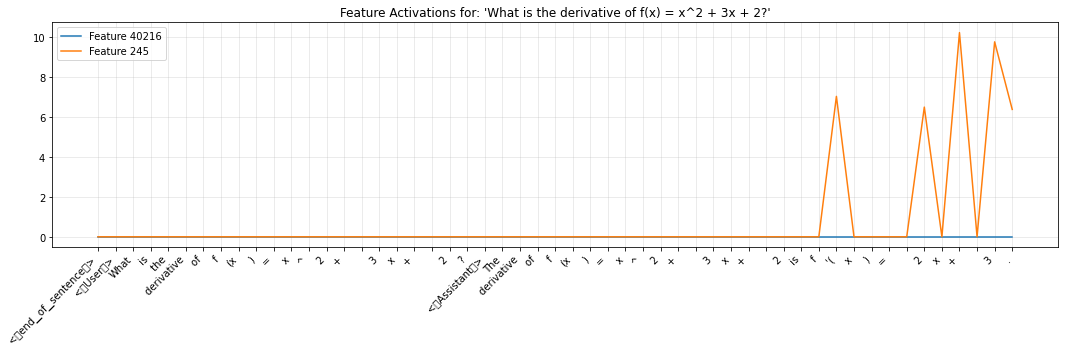

,Token,Feature 40216,Feature 245
0,<｜end▁of▁sentence｜>,0.0,0.000000
1,<｜User｜>,0.0,0.000000
2,What,0.0,0.000000
3,is,0.0,0.000000
4,the,0.0,0.000000
5,derivative,0.0,0.000000
6,of,0.0,0.000000
7,f,0.0,0.000000
8,(x,0.0,0.000000
9,),0.0,0.000000


In [12]:
example = "What is the derivative of f(x) = x^2 + 3x + 2?"
response = "The derivative of f(x) = x^2 + 3x + 2 is f'(x) = 2x + 3."
visualize_features(example, response, feature_ids=[df_sorted.iloc[10].feature_id, df_sorted.iloc[-10].feature_id])

/tmp/ipykernel_2209291/2054377050.py:63: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


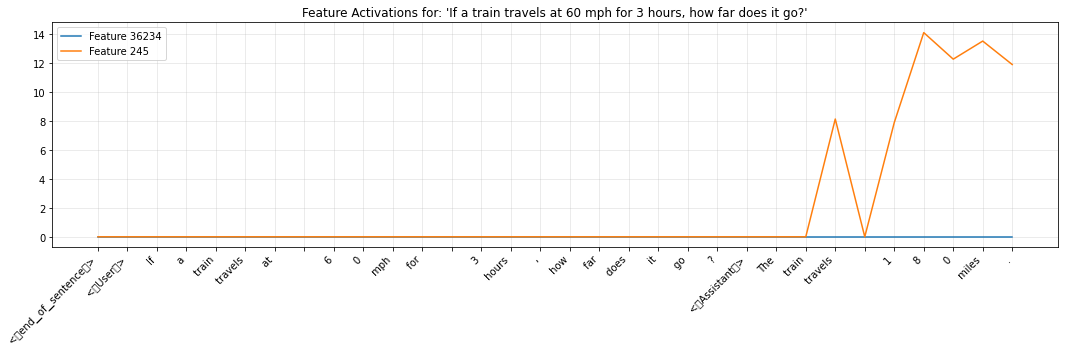

,Token,Feature 36234,Feature 245
0,<｜end▁of▁sentence｜>,0.0,0.000000
1,<｜User｜>,0.0,0.000000
2,If,0.0,0.000000
3,a,0.0,0.000000
4,train,0.0,0.000000
5,travels,0.0,0.000000
6,at,0.0,0.000000
7,,0.0,0.000000
8,6,0.0,0.000000
9,0,0.0,0.000000


In [ ]:
example = "If a train travels at 60 mph for 3 hours, how far does it go?"
response = "The train travels 180 miles."
visualize_features(example, response, feature_ids=[df_sorted.iloc[0].feature_id, df_sorted.iloc[-10].feature_id])

/tmp/ipykernel_2209291/2054377050.py:63: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


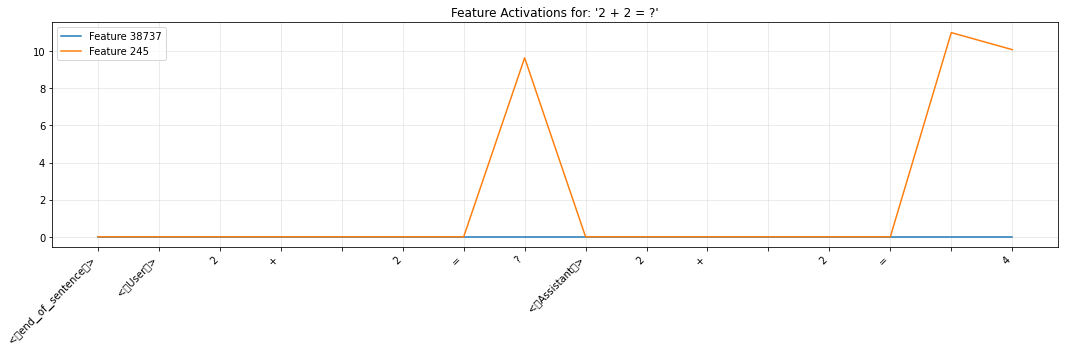

,Token,Feature 38737,Feature 245
0,<｜end▁of▁sentence｜>,0.0,0.000000
1,<｜User｜>,0.0,0.000000
2,2,0.0,0.000000
3,+,0.0,0.000000
4,,0.0,0.000000
5,2,0.0,0.000000
6,=,0.0,0.000000
7,?,0.0,9.641452
8,<｜Assistant｜>,0.0,0.000000
9,2,0.0,0.000000


In [37]:
example = "2 + 2 = ?"
response = "2 + 2 = 4"
visualize_features(example, response, feature_ids=[df_sorted.iloc[10].feature_id, df_sorted.iloc[-10].feature_id])

/tmp/ipykernel_2209291/4147184920.py:63: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


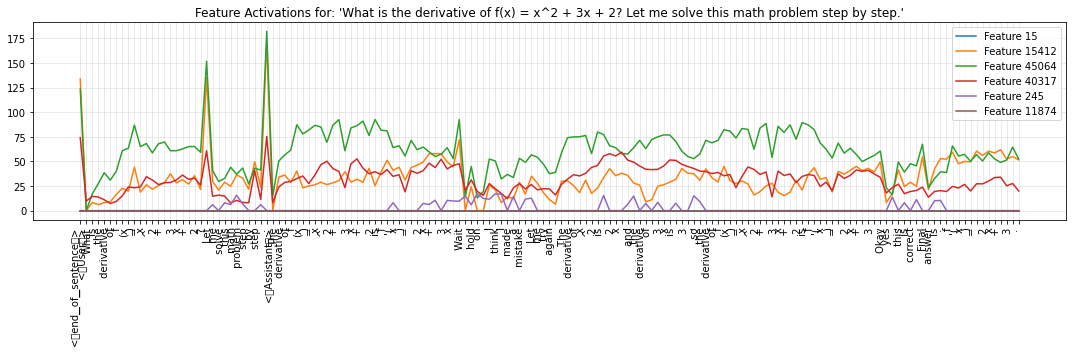

,Token,Feature 15,Feature 15412,Feature 45064,Feature 40317,Feature 245,Feature 11874
0,<｜end▁of▁sentence｜>,0.0,134.021957,123.577515,74.223022,0.0,0.0
1,<｜User｜>,0.0,0.000000,0.000000,9.604660,0.0,0.0
2,What,0.0,8.258582,16.950058,14.485341,0.0,0.0
3,is,0.0,6.061279,27.462469,13.834826,0.0,0.0
4,the,0.0,8.033601,38.491501,10.955769,0.0,0.0
...,...,...,...,...,...,...,...
152,x,0.0,58.642902,52.547874,33.619770,0.0,0.0
153,+,0.0,61.889996,49.007797,34.006195,0.0,0.0
154,,0.0,52.305267,51.313778,25.155598,0.0,0.0
155,3,0.0,54.996326,64.464340,27.565243,0.0,0.0


In [51]:
example = "What is the derivative of f(x) = x^2 + 3x + 2? Let me solve this math problem step by step."
response = "The derivative of f(x) = x^2 + 3x + 2 is f'(x) = 2x + 3x. Wait, hold on, I think I made a mistake. Let me try again. The derivative of x^2 is 2x, and the derivative of 3x is 3, so the derivative of f(x) = x^2 + 3x + 2 is f'(x) = 2x + 3. Okay yes, this is correct. Final answer is: f'(x) = 2x + 3."
visualize_features(example, response, feature_ids=[15, 15412, 45064, 40317, 245, 11874])

In [38]:
def find_top_activating_tokens(feature_ids: List[int], num_examples: int = 10, limit: int = 10000):
    """Find tokens that most strongly activate specific features
    
    Args:
        feature_ids: List of feature IDs to analyze
        num_examples: Number of top examples to return per feature
        limit: Maximum number of dataset examples to process
    
    Returns:
        Dictionary mapping feature IDs to DataFrames of top activating tokens
    """
    # Convert feature_ids to integers
    feature_ids = [int(feature_id) for feature_id in feature_ids]
    
    # Load the dataset
    dataset = load_dataset("ServiceNow-AI/R1-Distill-SFT", "v1", split="train", streaming=False)
    dataset = dataset.shuffle(seed=42)  
    print(f"Loaded {len(dataset)} examples from dataset")
    
    # Dictionary to store top activations for each feature
    all_top_activations = {feature_id: [] for feature_id in feature_ids}
    
    for i, example in enumerate(tqdm(dataset, total=min(limit, len(dataset)))):
        if i >= limit:
            break
        
        prompt = example["reannotated_messages"][0]["content"]
        response = example["reannotated_messages"][1]["content"]
        
        features, tokens = get_crosscoder_activations(prompt, response)
        
        # Process each feature
        for feature_id in feature_ids:
            # Get activations for this feature
            feature_acts = features[0, :, feature_id].cpu().numpy()
            
            # Find top activating positions
            top_indices = np.argsort(feature_acts)[-num_examples:][::-1]
            
            for idx in top_indices:
                if feature_acts[idx] > 0:  # Only include positive activations
                    token = r1_tokenizer.decode(tokens[0, idx])
                    all_top_activations[feature_id].append({
                        'token': token,
                        'activation': float(feature_acts[idx]),
                        'context': prompt[:100] + "..." if len(prompt) > 100 else prompt
                    })
    
    # Sort and create DataFrames for each feature
    results = {}
    for feature_id in feature_ids:
        # Sort by activation strength
        sorted_activations = sorted(all_top_activations[feature_id], key=lambda x: x['activation'], reverse=True)
        
        # Create DataFrame with top examples
        df = pd.DataFrame(sorted_activations[:num_examples])
        
        # Store in results
        results[feature_id] = df
        
        # Display results
        print(f"\n--- Top activations for Feature {feature_id} ---")
        display(df)
    
    return results

In [43]:
def analyze_backtracking_features():
    """Analyze features that correlate with backtracking in reasoning steps"""
    
    # Path to the results directory
    base_path = "../trees-of-reasoning/results/level4/deepseek-r1-distill-qwen-1.5b"
    
    # Collect backtracking phrases and contexts
    backtracking_data = []
    
    # Iterate through problem directories
    problem_dirs = [d for d in os.listdir(base_path) if d.startswith("problem_")]
    
    for problem_dir in problem_dirs:
        problem_path = os.path.join(base_path, problem_dir)
        
        # Get problem info
        with open(os.path.join(problem_path, "problem_info.json"), "r") as f:
            problem_info = json.load(f)
        
        # Get solution files
        solution_files = [f for f in os.listdir(problem_path) if f.startswith("solution_seed_") and f.endswith(".json")]
        
        for solution_file in solution_files:
            with open(os.path.join(problem_path, solution_file), "r") as f:
                solution_data = json.load(f)
            
            # Check if solution has backtracking
            if solution_data.get("has_backtracking", False):
                backtracking_phrases = solution_data.get("backtracking_phrases", [])
                reasoning_steps = solution_data.get("reasoning_steps", [])
                
                # Find contexts where backtracking phrases appear
                for phrase in backtracking_phrases:
                    for step in reasoning_steps:
                        if phrase.lower() in step.lower():
                            backtracking_data.append({
                                "problem_id": problem_info["problem_id"],
                                "problem_type": problem_info["problem_type"],
                                "backtracking_phrase": phrase,
                                "context": step,
                                "is_correct": solution_data.get("is_correct", False)
                            })
    
    # Create DataFrame
    df_backtracking = pd.DataFrame(backtracking_data)
    
    print(f"Found {len(df_backtracking)} backtracking instances")
    
    # Get feature activations for backtracking phrases
    backtracking_activations = {}
    
    for i, row in tqdm(df_backtracking.iterrows(), total=len(df_backtracking)):
        phrase = row["backtracking_phrase"]
        context = row["context"]
        
        # Create a simple prompt-response pair to analyze
        prompt = "Solve this math problem step by step."
        response = context
        
        features, tokens = get_crosscoder_activations(prompt, response)
        
        # Find the token positions that correspond to the backtracking phrase
        token_ids = r1_tokenizer.encode(response)
        phrase_token_ids = r1_tokenizer.encode(phrase)
        
        # Find all occurrences of the phrase in the tokenized response
        for i in range(len(token_ids) - len(phrase_token_ids) + 1):
            if token_ids[i:i+len(phrase_token_ids)] == phrase_token_ids:
                # Get feature activations for these tokens
                for j in range(i, i+len(phrase_token_ids)):
                    if j < features.shape[1]:
                        feature_acts = features[0, j, :].cpu().numpy()
                        
                        # Store top activating features
                        top_indices = np.argsort(feature_acts)[-10:][::-1]
                        for idx in top_indices:
                            if feature_acts[idx] > 0:
                                if idx not in backtracking_activations:
                                    backtracking_activations[idx] = []
                                backtracking_activations[idx].append({
                                    'phrase': phrase,
                                    'context': context,
                                    'activation': float(feature_acts[idx])
                                })
    
    # Sort features by total activation strength
    feature_strengths = {}
    for feature_id, activations in backtracking_activations.items():
        feature_strengths[feature_id] = sum(a['activation'] for a in activations)
    
    top_backtracking_features = sorted(feature_strengths.items(), key=lambda x: x[1], reverse=True)[:10]
    
    print("\nTop features associated with backtracking:")
    for feature_id, strength in top_backtracking_features:
        print(f"Feature {feature_id}: Total activation {strength:.2f}")
        
        # Show examples
        examples = sorted(backtracking_activations[feature_id], key=lambda x: x['activation'], reverse=True)[:3]
        for ex in examples:
            print(f"  - '{ex['phrase']}' in '{ex['context'][:50]}...' (activation: {ex['activation']:.2f})")
    
    return top_backtracking_features, df_backtracking

In [44]:
def analyze_model_differences():
    """Analyze differences between base and R1 model reasoning"""
    
    # Paths to the results directories
    r1_path = "../trees-of-reasoning/results/level4/deepseek-r1-distill-qwen-1.5b"
    base_path = "../trees-of-reasoning/results/level4/qwen2.5-math-1.5b"
    
    # Collect data from both models
    r1_data = []
    base_data = []
    
    # Process R1 model data
    problem_dirs = [d for d in os.listdir(r1_path) if d.startswith("problem_")]
    for problem_dir in problem_dirs:
        problem_path = os.path.join(r1_path, problem_dir)
        
        # Get problem info
        with open(os.path.join(problem_path, "problem_info.json"), "r") as f:
            problem_info = json.load(f)
        
        # Get solution files
        solution_files = [f for f in os.listdir(problem_path) if f.startswith("solution_seed_") and f.endswith(".json")]
        
        for solution_file in solution_files:
            with open(os.path.join(problem_path, solution_file), "r") as f:
                solution_data = json.load(f)
            
            reasoning_steps = solution_data.get("reasoning_steps", [])
            has_backtracking = solution_data.get("has_backtracking", False)
            is_correct = solution_data.get("is_correct", False)
            
            r1_data.append({
                "problem_id": problem_info["problem_id"],
                "problem_type": problem_info["problem_type"],
                "reasoning_steps": reasoning_steps,
                "has_backtracking": has_backtracking,
                "is_correct": is_correct,
                "model": "r1"
            })
    
    # Process base model data
    problem_dirs = [d for d in os.listdir(base_path) if d.startswith("problem_")]
    for problem_dir in problem_dirs:
        problem_path = os.path.join(base_path, problem_dir)
        
        # Get problem info
        try:
            with open(os.path.join(problem_path, "problem_info.json"), "r") as f:
                problem_info = json.load(f)
                
            # Get reasoning tree
            with open(os.path.join(problem_path, "reasoning_tree.graphml"), "r") as f:
                tree_content = f.read()
                
            # Extract reasoning steps from graphml (simplified approach)
            reasoning_steps = []
            for line in tree_content.split('\n'):
                if '<data key="d2">' in line and '<data key="d1">normal</data>' in tree_content.split(line)[1].split('\n')[0]:
                    step = line.split('<data key="d2">')[1].split('</data>')[0]
                    reasoning_steps.append(step)
            
            base_data.append({
                "problem_id": problem_info["problem_id"],
                "problem_type": problem_info["problem_type"],
                "reasoning_steps": reasoning_steps,
                "has_backtracking": False,  # Base model doesn't have explicit backtracking
                "is_correct": True,  # Assuming ground truth solutions are correct
                "model": "base"
            })
        except:
            continue
    
    # Create DataFrames
    df_r1 = pd.DataFrame(r1_data)
    df_base = pd.DataFrame(base_data)
    
    print(f"R1 model: {len(df_r1)} solutions")
    print(f"Base model: {len(df_base)} solutions")
    
    # Analyze differences in reasoning
    r1_text = " ".join([" ".join(steps) for steps in df_r1["reasoning_steps"]])
    base_text = " ".join([" ".join(steps) for steps in df_base["reasoning_steps"]])
    
    # Get feature activations for both models
    r1_features, _ = get_crosscoder_activations("Math problem:", r1_text[:1000])
    base_features, _ = get_crosscoder_activations("Math problem:", base_text[:1000])
    
    # Compare feature activations
    r1_mean = r1_features.mean(dim=1).cpu().numpy()[0]
    base_mean = base_features.mean(dim=1).cpu().numpy()[0]
    
    # Find features with largest differences
    feature_diffs = r1_mean - base_mean
    top_r1_features = np.argsort(feature_diffs)[-10:][::-1]
    top_base_features = np.argsort(feature_diffs)[:10]
    
    print("\nTop features more active in R1 model:")
    for feature_id in top_r1_features:
        print(f"Feature {feature_id}: Difference {feature_diffs[feature_id]:.4f}")
    
    print("\nTop features more active in base model:")
    for feature_id in top_base_features:
        print(f"Feature {feature_id}: Difference {feature_diffs[feature_id]:.4f}")
    
    return top_r1_features, top_base_features, feature_diffs

In [45]:
# First, analyze the differences between base and R1 models
top_r1_features, top_base_features, feature_diffs = analyze_model_differences()

# Then, analyze features associated with backtracking
top_backtracking_features, df_backtracking = analyze_backtracking_features()

# Finally, find top activating tokens for the most interesting features
# Combine the most interesting features from both analyses
interesting_features = list(set([f[0] for f in top_backtracking_features[:5]] + list(top_r1_features[:5]) + list(top_base_features[:5])))

# Find tokens that activate these features
feature_results = find_top_activating_tokens(interesting_features)

# Analyze common backtracking phrases
common_phrases = df_backtracking["backtracking_phrase"].value_counts().head(10)
print("\nMost common backtracking phrases:")
print(common_phrases)

R1 model: 239 solutions
Base model: 2 solutions

Top features more active in R1 model:
Feature 5542: Difference 12.7198
Feature 245: Difference 4.6556
Feature 2646: Difference 4.4531
Feature 12057: Difference 3.6755
Feature 35260: Difference 3.4153
Feature 46891: Difference 3.1732
Feature 12884: Difference 2.9420
Feature 34465: Difference 2.9163
Feature 17017: Difference 2.7934
Feature 25699: Difference 2.6579

Top features more active in base model:
Feature 33581: Difference -47.6969
Feature 2107: Difference -47.5397
Feature 45064: Difference -36.3155
Feature 14407: Difference -24.3437
Feature 15412: Difference -22.6783
Feature 25407: Difference -21.5195
Feature 17409: Difference -19.7144
Feature 44017: Difference -19.5902
Feature 42388: Difference -18.6086
Feature 40317: Difference -16.8422
Found 1962 backtracking instances


100%|██████████| 1962/1962 [02:03<00:00, 15.84it/s]



Top features associated with backtracking:
Feature 15412: Total activation 934.89
  - 'wait' in 'wait, 3 goes into 8 two times, which is 6, with a ...' (activation: 133.64)
  - 'wait' in 'wait, 3 goes into 8 twice, which is 6, with a rema...' (activation: 133.64)
  - 'wait' in 'wait, 3 goes into 8 twice, which is 6, with a rema...' (activation: 133.64)
Feature 45064: Total activation 861.15
  - 'wait' in 'wait, 3 goes into 8 two times, which is 6, with a ...' (activation: 123.05)
  - 'wait' in 'wait, 3 goes into 8 twice, which is 6, with a rema...' (activation: 123.05)
  - 'wait' in 'wait, 3 goes into 8 twice, which is 6, with a rema...' (activation: 123.05)
Feature 40317: Total activation 516.85
  - 'wait' in 'wait, 3 goes into 8 two times, which is 6, with a ...' (activation: 73.92)
  - 'wait' in 'wait, 3 goes into 8 twice, which is 6, with a rema...' (activation: 73.92)
  - 'wait' in 'wait, 3 goes into 8 twice, which is 6, with a rema...' (activation: 73.92)
Feature 25407: Total ac

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/51 [00:00<?, ?it/s]

...


--- Top activations for Feature 40317 ---


,token,activation,context
0,ஹ,1329.681519,ஹுரோஷிமா தினம் எப்போது அனுசரிக்கப்படுகிறது?
1,Ƙ,1208.543579,Ƙirƙiri labarin don kanun labarai mai zuwa: Ko...
2,🇰,1000.998169,🇰🇬 Манас эпосу 📚\nМанастагы көркөм фактылар ме...
3,Ẹ,998.273743,"Ẹwọn ọrinlelẹgbẹrun ọdun (1,800), ni wọn ju Ab..."
4,ል,916.341309,ትልቋ የሴኔጋል ከተማ ምን ያህል ነዋሪዎች አሏት?
5,👨,442.933258,👨‍⚕️ Кыргызстандагы белгилүү хирург Мамбет Мам...
6,<think>,439.799286,chào
7,🇬,313.710114,🇰🇬 Манас эпосу 📚\nМанастагы көркөм фактылар ме...
8,�,309.559021,ትልቋ የሴኔጋል ከተማ ምን ያህል ነዋሪዎች አሏት?
9,\n,306.900238,"Repeat this string ""coffee and flower"""



--- Top activations for Feature 25407 ---


,token,activation,context
0,</think>,78.450592,"If the radius of a circle is $\frac{1}{2}$, th..."
1,أسب,78.339622,أريد إيجاد عنوان مناسب للنص التالي: بعثت جمعية...
2,<think>,77.628319,Prove that a line that forms equal angles with...
3,<｜Assistant｜>,77.526093,விடை வகைகளை விளக்குக.
4,<｜Assistant｜>,77.443420,A text is given in Tamil. Translate it from th...
5,أسب,77.385719,பட்டு ஆடைகளுக்கு புகழ்பெற்ற நாடு எது?
6,<｜Assistant｜>,77.290604,बॉइल्ड एग मसाला फ्राय\nलागणारे जिन्नस:
7,<think>,77.043015,Create a program that will count the number of...
8,<｜Assistant｜>,76.800873,"Namna ya kuandaa kachumbari,"
9,<think>,76.644684,Write a Python code snippet to print the uniqu...



Most common backtracking phrases:
wait                        1367
let me double-check          176
i made a mistake             108
actually                      96
i need to check               64
hold on                       52
i think i made a mistake      31
let me verify                 29
that's not right              17
let me try again              10
Name: backtracking_phrase, dtype: int64
